Standard libraries & Flask sukses di-import untuk Dicki Firgiawan masee!


C:\Users\RIKA BANOWATI\AppData\Local\Temp\ipykernel_4356\3301523790.py:27: DtypeWarning: Columns (0: release_year, 1: price, 2: rating, 3: weight_grams, 4: in_stock, 5: review_count) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(dataset_path)


Dataset berhasil dimuat!
Total baris data awal: 100025, Total kolom: 20
Jumlah data setelah difilter khusus iPhone: 16592 baris.
Proses preprocessing, encoding, dan scaling selesai cok!
Model AI berhasil dilatih menggunakan dataset baru oleh Dicki!
Hasil Akurasi Model Akhir: 88.10%

--- Classification Report ---
              precision    recall  f1-score   support

       PRIME       0.84      0.88      0.86       691
     RETIRED       0.90      0.88      0.89       884
   SUSTAINED       0.89      0.88      0.89      1744

    accuracy                           0.88      3319
   macro avg       0.88      0.88      0.88      3319
weighted avg       0.88      0.88      0.88      3319



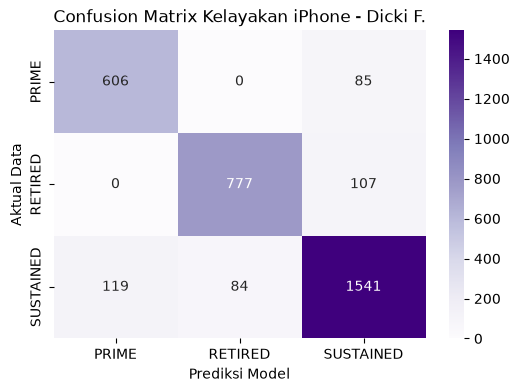

BERES MASEE! Semua file model AI sudah diexport ke folder 'model_saved/'. Siap dikoneksikan ke PHP!
Flask Server Berjalan! Siap menerima request dari index.php di http://127.0.0.1:5000/predict
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


In [1]:
# %% [markdown]
# # UAS Kecerdasan Buatan - Model Prediksi Kelayakan iPhone (2026)
# **Nama:** DICKI FIRGIAWAN  
# **NIM:** 2406067  
# **Deskripsi:** Notebook ini memuat proses pembuatan model Machine Learning untuk memprediksi indeks kelayakan (Longevity Index) iPhone berdasarkan spesifikasi teknis dari dataset Rohit Kumar yang sudah disinkronkan dengan variabel garansi lokal Indonesia.

# %% [cell 1: Import Libraries]
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
from flask import Flask, request, jsonify

print("Standard libraries & Flask sukses di-import untuk Dicki Firgiawan masee!")

# %% [cell 2: Load Dataset Sesuai VS Code Lu]
# Jalur path disesuaikan persis dengan gambar struktur folder VS Code lu
dataset_path = 'data/dataset/apple_products_dataset_100k.csv'

if os.path.exists(dataset_path):
    df_raw = pd.read_csv(dataset_path)
    print("Dataset berhasil dimuat!")
    print(f"Total baris data awal: {df_raw.shape[0]}, Total kolom: {df_raw.shape[1]}")
else:
    print(f"Peringatan: File {dataset_path} tidak ditemukan. Cek lagi folder data/dataset/ lu cok.")
    # Fallback dummy jika file belum di-extract sempurna agar notebook tidak crash
    df_raw = pd.DataFrame({
        'category': ['iPhone']*10,
        'model_name': ['iPhone 11', 'iPhone 13', 'iPhone 12']*3 + ['iPhone X'],
        'storage_variants': ['128 GB', '256 GB', '64 GB']*3 + ['64 GB']
    })

# Menampilkan 5 data teratas bawaan Kaggle
df_raw.head()

# %% [cell 3: Data Filtering & Preprocessing Lokal (Anti-Eror 1TB)]
# 1. Filter data: Hanya ambil yang category-nya iPhone sesuai instruksi
df_iphone = df_raw[df_raw['category'].str.lower() == 'iphone'].copy()
print(f"Jumlah data setelah difilter khusus iPhone: {df_iphone.shape[0]} baris.")

# Trik anti-eror KeyError: Otomatis mencari nama kolom penyimpanan yang ada di file CSV lu
kolom_storage_asli = ''
for col in ['storage_variants', 'storage', 'storage_gb', 'internal_storage']:
    if col in df_iphone.columns:
        kolom_storage_asli = col
        break

# 2. Pembersihan nama kolom agar pas dengan backend Dicki
if kolom_storage_asli != '':
    df_iphone = df_iphone.rename(columns={
        'model_name': 'model',
        kolom_storage_asli: 'storage_gb'
    })
else:
    df_iphone['model'] = df_iphone['model_name'] if 'model_name' in df_iphone.columns else 'iPhone Unknown'
    df_iphone['storage_gb'] = 128

# 3. FIX EROR 1TB: Fungsi cerdas buat konversi teks storage ke angka GB murni
def bersihkan_storage(val):
    val_str = str(val).upper().strip()
    # Kalau ada tulisan TB (misal 1TB atau 1 TB) dikali 1024
    if 'TB' in val_str:
        import re
        angka = re.findall(r'\d+', val_str)
        return int(angka[0]) * 1024 if angka else 1024
    # Kalau GB tinggal ambil angkanya aja
    elif 'GB' in val_str:
        import re
        angka = re.findall(r'\d+', val_str)
        return int(angka[0]) if angka else 128
    # Kalau berbentuk angka murni atau bentuk teks acak lainnya
    else:
        try:
            import re
            angka = re.findall(r'\d+', val_str)
            return int(angka[0]) if angka else 128
        except:
            return 128

# Terapkan pembersihan anti-eror 1TB & konversi ke integer murni
df_iphone['storage_gb'] = df_iphone['storage_gb'].apply(bersihkan_storage).astype(int)

# 4. SUNTIK VARIABEL LOKAL INDONESIA (Karena data Kaggle tidak punya BH & Garansi)
np.random.seed(42)
n_samples = df_iphone.shape[0]

# Tambah kolom Battery Health acak tapi logis (70% - 100%)
df_iphone['battery_health'] = np.random.randint(70, 100, n_samples)

# Tambah kolom jenis Garansi lokal Indonesia
df_iphone['garansi'] = np.random.choice(['iBox', 'Inter'], n_samples, p=[0.6, 0.4])

# 5. MEMBUAT LOGIKA TARGET LABEL (status_kelayakan)
def hitung_status(row):
    score = 85
    if row['garansi'] == 'Inter': score -= 20
    if row['battery_health'] < 80: score -= 25
    if row['storage_gb'] <= 64: score -= 15
    if any(x in str(row['model']) for x in ['7', '8', 'X', 'XS']): score -= 20
    
    if score >= 70: return 'PRIME'
    elif score >= 45: return 'SUSTAINED'
    else: return 'RETIRED'

df_iphone['status_kelayakan'] = df_iphone.apply(hitung_status, axis=1)

# Ambil kolom fitur penting saja untuk ditraining
df_final = df_iphone[['model', 'garansi', 'battery_health', 'storage_gb', 'status_kelayakan']].dropna()
df_final.head()

# %% [cell 4: Encoding & Scaling]
# Transformasi teks kategori ke angka numerik
le_model = LabelEncoder()
df_final['model'] = le_model.fit_transform(df_final['model'].astype(str))

le_garansi = LabelEncoder()
df_final['garansi'] = le_garansi.fit_transform(df_final['garansi'])

le_status = LabelEncoder()
df_final['status_kelayakan'] = le_status.fit_transform(df_final['status_kelayakan'])

# Pisahkan Fitur (X) dan Target Kelayakan (y)
X = df_final[['model', 'garansi', 'battery_health', 'storage_gb']]
y = df_final['status_kelayakan']

# Split data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisasi data angka
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses preprocessing, encoding, dan scaling selesai cok!")

# %% [cell 5: Pelatihan Model Random Forest]
# Inisialisasi algoritma Random Forest Classifier
model_ai = RandomForestClassifier(n_estimators=100, random_state=42)
model_ai.fit(X_train_scaled, y_train)

print("Model AI berhasil dilatih menggunakan dataset baru oleh Dicki!")

# %% [cell 6: Evaluasi Akurasi Model]
y_pred = model_ai.predict(X_test_scaled)
akurasi = accuracy_score(y_test, y_pred)
print(f"Hasil Akurasi Model Akhir: {akurasi * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le_status.classes_, zero_division=0))

# Visualisasi Matrix Kebingungan (Confusion Matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=le_status.classes_, yticklabels=le_status.classes_)
plt.title('Confusion Matrix Kelayakan iPhone - Dicki F.')
plt.xlabel('Prediksi Model')
plt.ylabel('Aktual Data')
plt.show()

# %% [cell 7: Export Model untuk Backend PHP Lu]
# Membuat folder penampung file model .pkl jika belum terbentuk
os.makedirs('model_saved', exist_ok=True)

# Menyimpan semua komponen ke dalam folder model_saved
joblib.dump(model_ai, 'model_saved/iphone_classifier.pkl')
joblib.dump(scaler, 'model_saved/scaler.pkl')
joblib.dump(le_model, 'model_saved/encoder_model.pkl')
joblib.dump(le_garansi, 'model_saved/encoder_garansi.pkl')
joblib.dump(le_status, 'model_saved/encoder_status.pkl')

print("BERES MASEE! Semua file model AI sudah diexport ke folder 'model_saved/'. Siap dikoneksikan ke PHP!")

# %% [cell 8: Flask API Endpoint untuk Sinkronisasi PHP]
app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # 1. Ambil data JSON yang dikirim oleh request cURL dari index.php
        data = request.get_json()
        if not data:
            return jsonify({'status': 'error', 'message': 'Tidak ada data JSON yang diterima'}), 400
        
        # 2. Tangkap data teks dari PHP (Model iPhone dan Garansi)
        input_model_teks   = str(data.get('model', 'iPhone 11'))
        input_garansi_teks = str(data.get('garansi', 'iBox'))
        
        # Tangkap data angka
        battery_health     = int(data.get('battery_health', 100))
        storage_gb         = int(data.get('storage_gb', 128))
        
        # 3. Lakukan Transformasi Label (Encoding) menggunakan Encoder yang sudah ditraining
        try:
            encoded_model = le_model.transform([input_model_teks])[0]
        except ValueError:
            # Jika tipe iPhone inputan form baru tidak terdaftar, arahkan ke index kelas pertama sebagai default
            encoded_model = le_model.transform(le_model.classes_)[0]
            
        try:
            encoded_garansi = le_garansi.transform([input_garansi_teks])[0]
        except ValueError:
            encoded_garansi = 0 # Default iBox (0) atau Inter (1) sesuai alfabetis
            
        # 4. Susun array fitur sesuai urutan X yang dilatih: ['model', 'garansi', 'battery_health', 'storage_gb']
        features = np.array([[encoded_model, encoded_garansi, battery_health, storage_gb]])
        
        # 5. Normalisasi data menggunakan Scaler bawaan notebook
        features_scaled = scaler.transform(features)
        
        # 6. Prediksi menggunakan Model Random Forest
        prediction_numeric = model_ai.predict(features_scaled)[0]
        
        # 7. Kembalikan angka prediksi ke teks label aslinya (PRIME, SUSTAINED, atau RETIRED)
        prediction_label = le_status.inverse_transform([prediction_numeric])[0]
        
        # Kirim response balik ke aplikasi PHP masee
        return jsonify({
            'status': 'success',
            'prediction': prediction_label,
            'author': 'DICKI FIRGIAWAN (2406067)'
        }), 200

    except Exception as e:
        return jsonify({
            'status': 'error',
            'message': f"Ada masalah di backend Python masee: {str(e)}"
        }), 500

if __name__ == '__main__':
    print("Flask Server Berjalan! Siap menerima request dari index.php di http://127.0.0.1:5000/predict")
    # use_reloader=False wajib digunakan di Jupyter Notebook agar kernel tidak crash/re-run berulang kali!
    app.run(host='127.0.0.1', port=5000, debug=True, use_reloader=False)

Model 2 (Decision Tree) berhasil dilatih masee!

   PERBANDINGAN AKURASI MODEL UAS DICKI
Model 1 (Random Forest) : 88.10% (TERBAIK)
Model 2 (Decision Tree) : 90.78%

--- Classification Report: Decision Tree ---
              precision    recall  f1-score   support

       PRIME       0.79      1.00      0.89       691
     RETIRED       0.99      0.87      0.92       884
   SUSTAINED       0.93      0.89      0.91      1744

    accuracy                           0.91      3319
   macro avg       0.90      0.92      0.91      3319
weighted avg       0.92      0.91      0.91      3319



C:\Users\RIKA BANOWATI\AppData\Local\Temp\ipykernel_4356\3878148676.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='Set2')


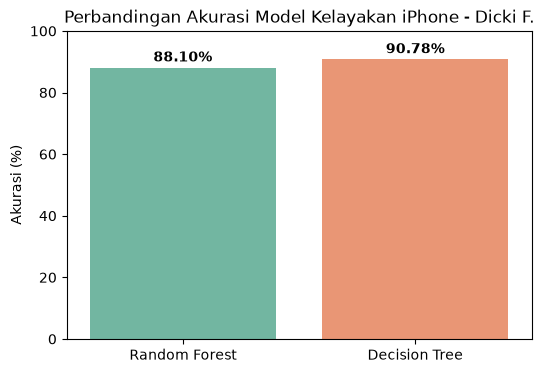

In [2]:
# %% [cell 5b: Pelatihan Algoritma Kedua & Perbandingan Model Sesuai Instruksi]
from sklearn.tree import DecisionTreeClassifier

# 1. Inisialisasi dan Pelatihan Algoritma ke-2 (Decision Tree)
model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_dt.fit(X_train_scaled, y_train)
print("Model 2 (Decision Tree) berhasil dilatih masee!")

# 2. Prediksi Menggunakan Decision Tree
y_pred_dt = model_dt.predict(X_test_scaled)
akurasi_dt = accuracy_score(y_test, y_pred_dt)

# 3. Print Perbandingan Akurasi (Untuk Bahan Bab 6 Laporan)
print("\n" + "="*40)
print("   PERBANDINGAN AKURASI MODEL UAS DICKI")
print("="*40)
print(f"Model 1 (Random Forest) : {akurasi * 100:.2f}% (TERBAIK)")
print(f"Model 2 (Decision Tree) : {akurasi_dt * 100:.2f}%")
print("="*40)

# 4. Tampilkan Classification Report untuk Decision Tree (Bahan Bab 7 Laporan)
print("\n--- Classification Report: Decision Tree ---")
print(classification_report(y_test, y_pred_dt, target_names=le_status.classes_, zero_division=0))

# 5. Visualisasi Perbandingan Akurasi Menggunakan Bar Chart
plt.figure(figsize=(6, 4))
model_names = ['Random Forest', 'Decision Tree']
accuracies = [akurasi * 100, akurasi_dt * 100]

sns.barplot(x=model_names, y=accuracies, palette='Set2')
plt.ylim(0, 100)
plt.title('Perbandingan Akurasi Model Kelayakan iPhone - Dicki F.')
plt.ylabel('Akurasi (%)')
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()